In [1]:
import matplotlib.pyplot as plt
%ls log
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"


ls: cannot access 'log': No such file or directory


In [6]:
import json
import glob
import pandas as pd 
import numpy as np
dense_level = "10000x5000"
df = pd.read_csv("/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/tests/log10.csv")
df

,isSparse,dense_level,sparsity_level,time,cuda_elapsed_time,rep
0,SparseUT,500x500,0,0.019740,19.795967,0
1,SparseUT,500x500,0,0.002454,5.864448,1
2,SparseUT,500x500,0,0.002473,5.843968,2
3,SparseUT,500x500,0,0.002396,5.844992,3
4,SparseUT,500x500,0,0.002445,5.846016,4
...,...,...,...,...,...,...
1675,SparseTorch,10000x5000,99,0.131888,132.226044,5
1676,SparseTorch,10000x5000,99,0.131503,131.847168,6
1677,SparseTorch,10000x5000,99,0.131527,131.870728,7
1678,SparseTorch,10000x5000,99,0.130839,131.179520,8


In [3]:
%%capture
fig, ax = plt.subplots(3,figsize=(8, 24));


In [4]:
%%capture
df_dlvl = df[df.dense_level == dense_level]
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

def plt_them(df_dlvl, ax=None):

    
    max_avg_s = 0
        
    for category, group in df_dlvl.groupby('isSparse'):
        avg_per_sparsity = group.groupby('sparsity_level')['cuda_elapsed_time'].mean() * 10
        std_per_sparsity = group.groupby('sparsity_level')['cuda_elapsed_time'].std() * 10
        sparsity_level = group.groupby('sparsity_level')['sparsity_level'].first()
        max_avg_s = max(max_avg_s, avg_per_sparsity.max())
        
        ax.plot(sparsity_level, avg_per_sparsity, marker='o', linestyle='-', label=category)
        ax.fill_between(sparsity_level, avg_per_sparsity - std_per_sparsity, avg_per_sparsity + std_per_sparsity, alpha=0.2)

    ax.set_xticks(list(range(0, 101, 5)))
    ax.set_yticks(np.linspace(0, max_avg_s, 40))
    
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    
    ax.set_title(f'Sparse Multiplication vs Dense Multiplication ({dense_level})')
    ax.set_xlabel('Sparsity Level')
    ax.set_ylabel('Cuda Time (in microseconds)')
    
    ax.legend(title='Multiplication Type')

    
    #return fig, ax  # Return figure and axis
plt_them(df_dlvl, ax=ax[0])

df_dlvl = df[df.dense_level == dense_level] 

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Group by the 'category' column and plot each group
df_dlvl=df_dlvl[df_dlvl.isSparse != 'SparseTorch']
plt_them(df_dlvl, ax=ax[1])



df_dlvl = df[df.dense_level == dense_level]
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Group by the 'category' column and plot each group
df_dlvl=df_dlvl[~df_dlvl.isSparse.isin(['SparseTorch', 'JaxSparse'])]
plt_them(df_dlvl, ax[2])


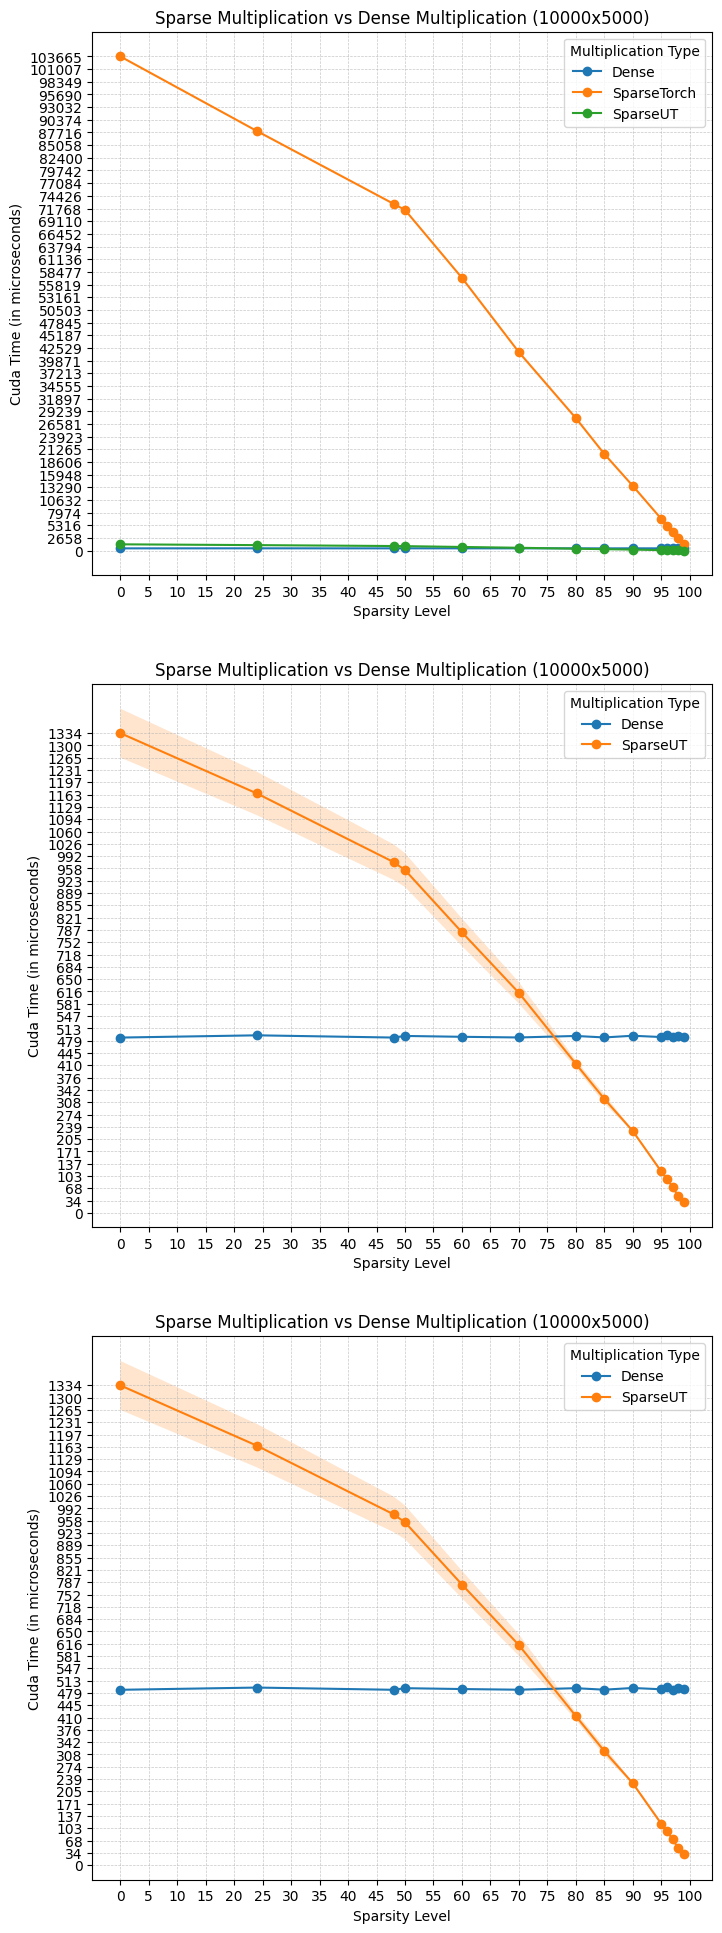

In [5]:
fig